In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

This prices dataset consists of forecasted GB electricity market prices for 8 different markets, obtained from a third party company in partnership with BP plc

In [22]:
prices_df = pd.read_csv('../data/GBCentralAllComplete_Prices.csv', index_col='Date', parse_dates=True)

we are only interested in future forecasted prices (not forecasted prices that have already occured)

In [23]:
prices_df = prices_df.drop(columns=['Unnamed: 0', 'WeatherYear', 'Year'], errors='ignore') #getting rid of unneccesary columns
prices_df = prices_df[prices_df.index >= '2026-01-01']
prices_df


,DCDMLow,DCDMHigh,DRLow,DRHigh,DayAhead,Intraday,BM,Imbalance
Date,,,,,,,,
2026-01-01 00:00:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-32.19576,-1.837328,-54.86949
2026-01-01 00:30:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.60295,5.635578,-54.86949
2026-01-01 01:00:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.60295,2.537015,-54.86927
2026-01-01 01:30:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.60295,-14.630521,-54.86970
2026-01-01 02:00:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.60295,-7.648162,-54.87098
...,...,...,...,...,...,...,...,...
2060-12-31 21:30:00,1.666407,0.075169,7.010102,-4.002441,30.006510,23.16498,28.561956,-16.99150
2060-12-31 22:00:00,1.666407,0.075169,7.010102,-4.002441,30.006510,24.32914,26.287658,20.41169
2060-12-31 22:30:00,1.666407,0.075169,7.010102,-4.002441,30.006510,18.08446,37.600984,-16.99150


The dataset consists of forecasted prices until 2060, however for the purpose of this project, we will only look at 10 years worth of prices as it is unlikely that a 30 year price forecast is reliable

In [24]:
prices_df = prices_df[prices_df.index <= '2036-01-01']
prices_df.to_csv('../data/GBCentralAllComplete_Prices.csv')
prices_df

,DCDMLow,DCDMHigh,DRLow,DRHigh,DayAhead,Intraday,BM,Imbalance
Date,,,,,,,,
2026-01-01 00:00:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-32.195760,-1.837328,-54.86949
2026-01-01 00:30:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.602950,5.635578,-54.86949
2026-01-01 01:00:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.602950,2.537015,-54.86927
2026-01-01 01:30:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.602950,-14.630521,-54.86970
2026-01-01 02:00:00,2.777708,0.086401,9.277966,-4.874955,0.000851,-33.602950,-7.648162,-54.87098
...,...,...,...,...,...,...,...,...
2035-12-31 22:00:00,4.971708,0.415218,15.171100,-4.064110,8.961514,1.789264,33.209133,-25.27900
2035-12-31 22:30:00,4.971708,0.415218,15.171100,-4.064110,8.961514,1.786918,22.930517,-25.27900
2035-12-31 23:00:00,4.971708,0.415218,15.171100,-4.064110,8.961514,1.749229,27.983149,-25.27900


Downsampled to daily mean (3653 rows) for plotting performance.


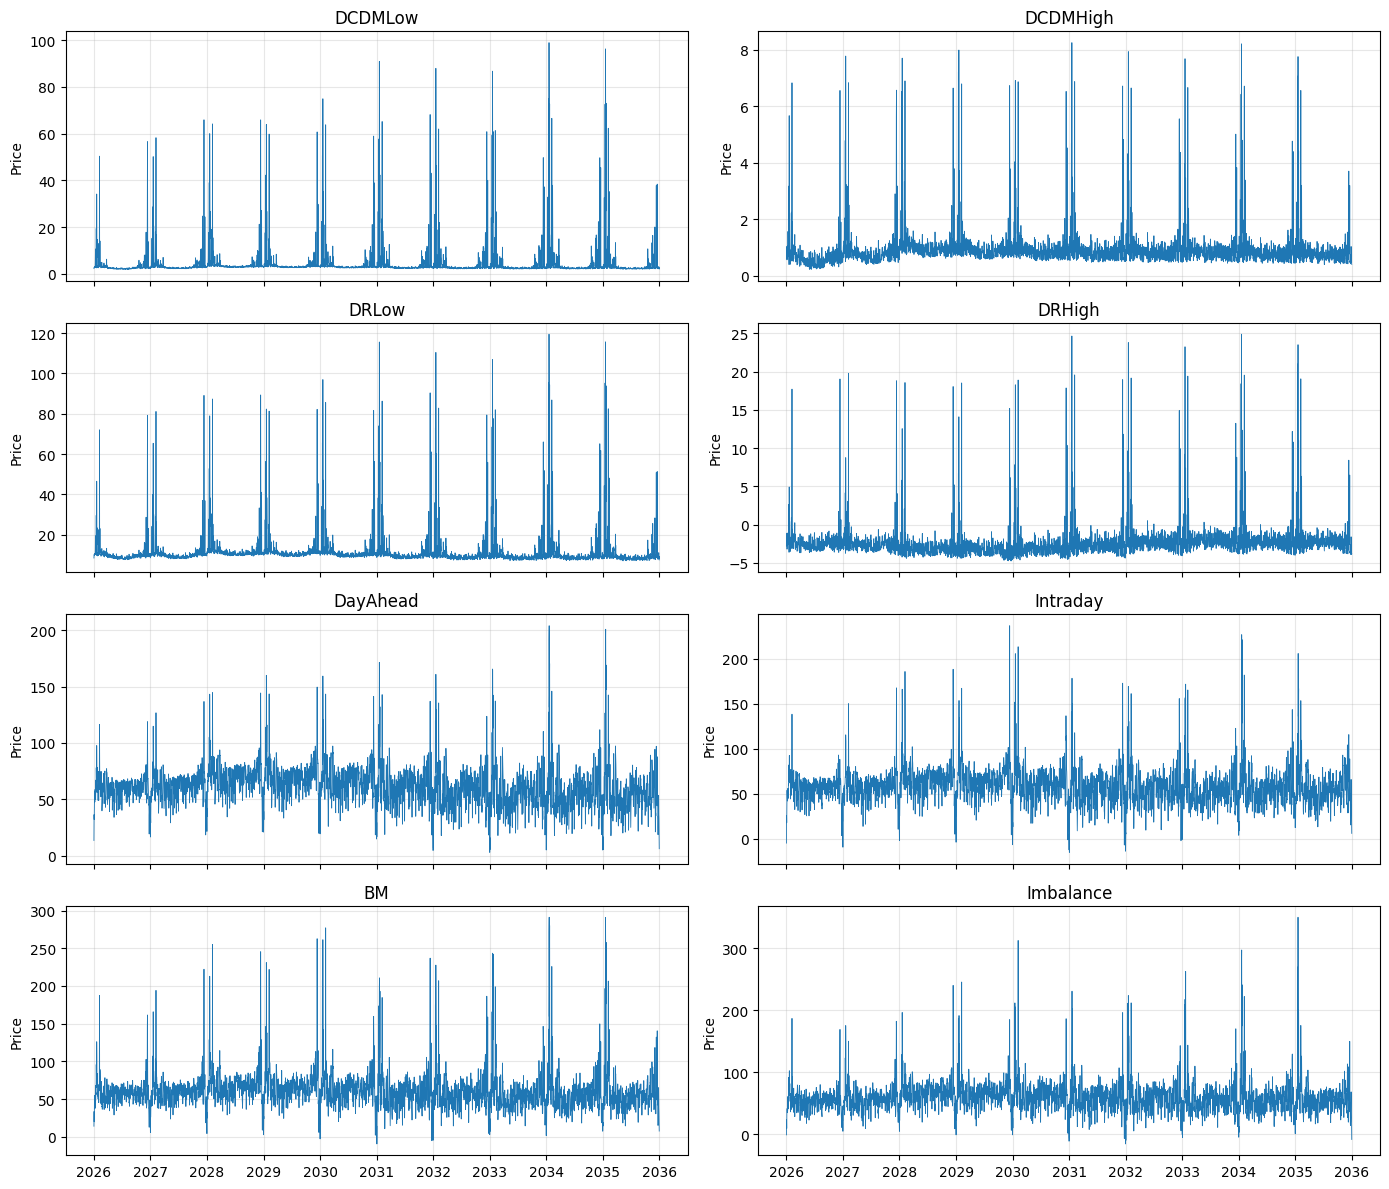

In [14]:
# plot each column over time in a 4x2 grid, downsampling to daily if the series is very large
df_plot = prices_df
if len(df_plot) > 200_000:
    df_plot = df_plot.resample('D').mean()
    print(f"Downsampled to daily mean ({len(df_plot)} rows) for plotting performance.")

cols = df_plot.columns.tolist()
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.plot(df_plot.index, df_plot[col], linewidth=0.6)
    ax.set_title(col)
    ax.set_ylabel('Price')
    ax.grid(alpha=0.3)

# hide any unused subplots (if any)
for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The above graphs show that markets such as DCDMHigh and DRHigh operate on a significantly lower price scale (peak of 10) compared to DayAhead and BM prices (peak > 300) 

All eight markts exhibit extreme fluctuations in the winter period, there are frequent excursions below £0/MWh in the Day for intraday. these represent periods of high renewable oversupply where the system is paying for flexible storage like BESS

The ancillary services (DCDMLow, DCDMHigh, DRLow, DRHigh) are less noisy and represent a more low risk - low reward option compared to the other 4 arbitrage markets

we should use scaling to ensure neural network gradients remain stable during training if opting for a Reinforcement Learning or other machine learning model. 

### Trend Analysis

we can use seasonal trend decomposition to visualise the trend of the prices over time

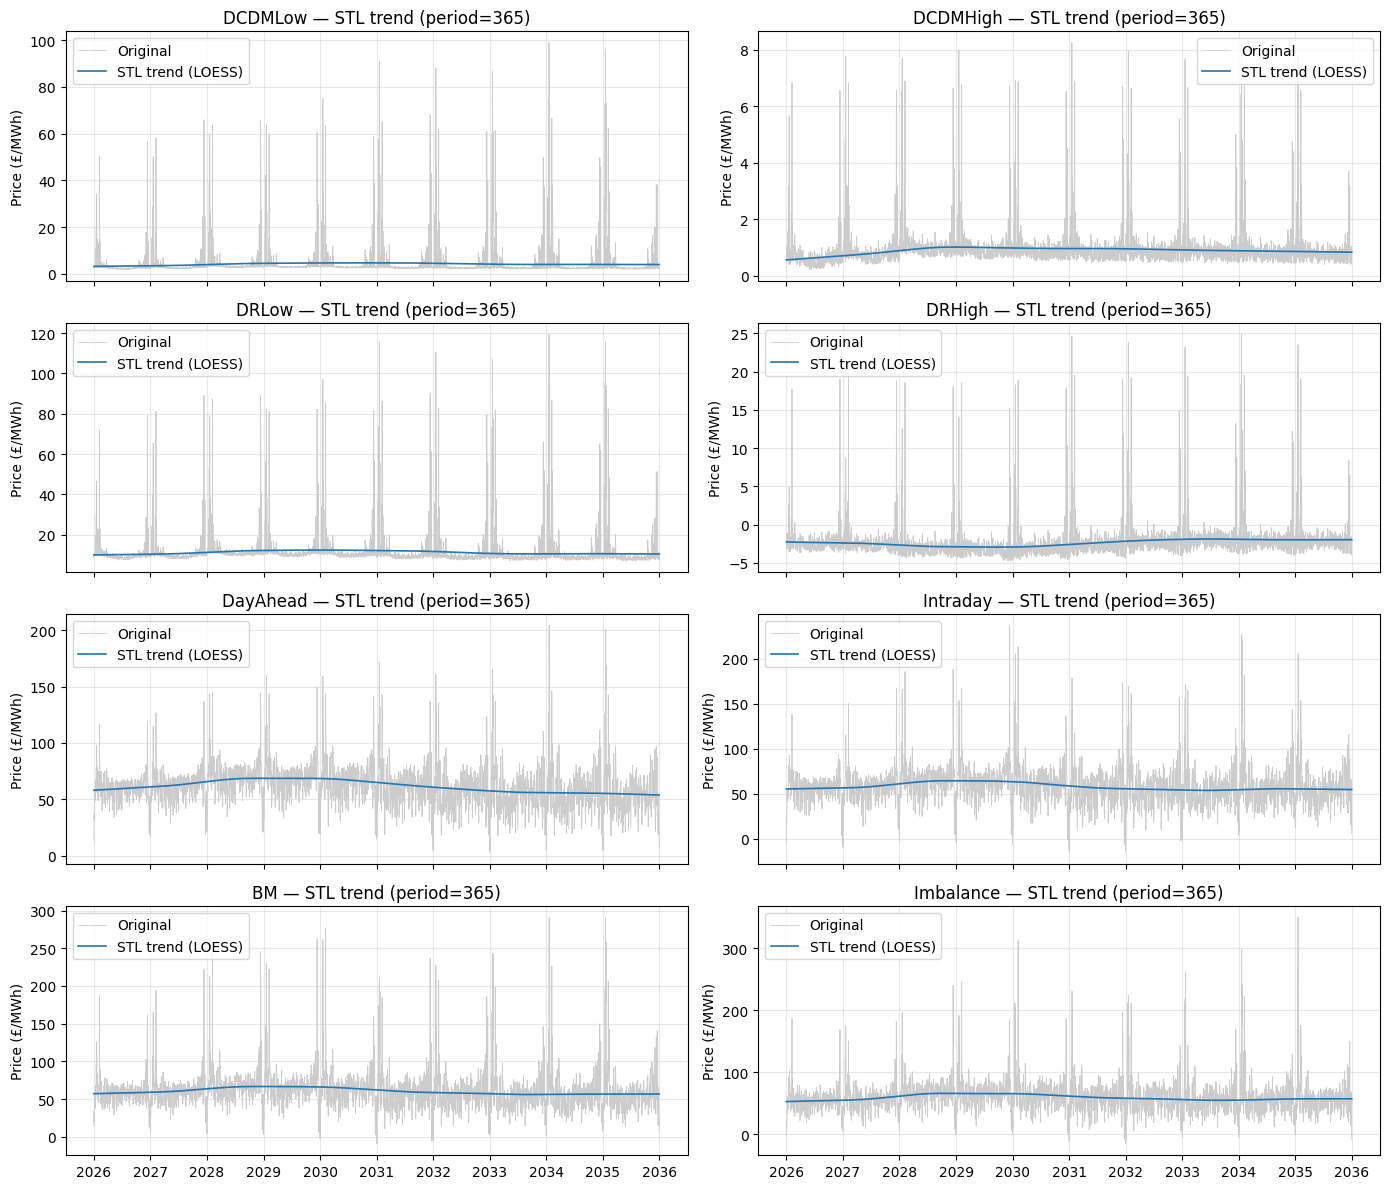

In [ ]:
# computing STL trend (LOESS) for each column
stl_trend = pd.DataFrame(index=df_plot.index)

for col in cols:
    s = df_plot[col].astype(float).copy()
    s = s.interpolate(method='time', limit_direction='both')  # fill any gaps
    res = STL(s, period=365, robust=True).fit()
    stl_trend[col] = res.trend

# plot original series and STL trend in a 4x2 grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.plot(df_plot.index, df_plot[col], color='0.8', linewidth=0.6, label='Original')
    ax.plot(stl_trend.index, stl_trend[col], color='tab:blue', linewidth=1.2, label='STL trend (LOESS)')
    ax.set_title(f"{col} — STL trend (period=365)")
    ax.set_ylabel('Price (£/MWh)')
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

there appears to be a consistent hump across markets around 2029-2030 and a gradual decline/stabilisation towards 2036

This suggests that there will be an influx of low marginal cost renewables coming online in the 2030s, we should assume that the highest revenue years will be in the first 5 years rather than the last 5 years of the time period.